# Experiment 1: Reward Model Miscalibration Under Deployment Shift

Static Bradley-Terry reward model trained under reference policy `π_ref` becomes miscalibrated as deployed policies `π_t` shift the output distribution. Calibration error should grow with `JS(D_{π_t}, D_{π_ref})`, with the rate scaling with `λ`.

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.environment import EnvironmentConfig, PreferenceEnvironment
from src.experiment1 import Experiment1Config, run_experiment1

RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

config = Experiment1Config(
    env=EnvironmentConfig(seed=42),
    seed=42,
)
print("Config ready.")

Config ready.


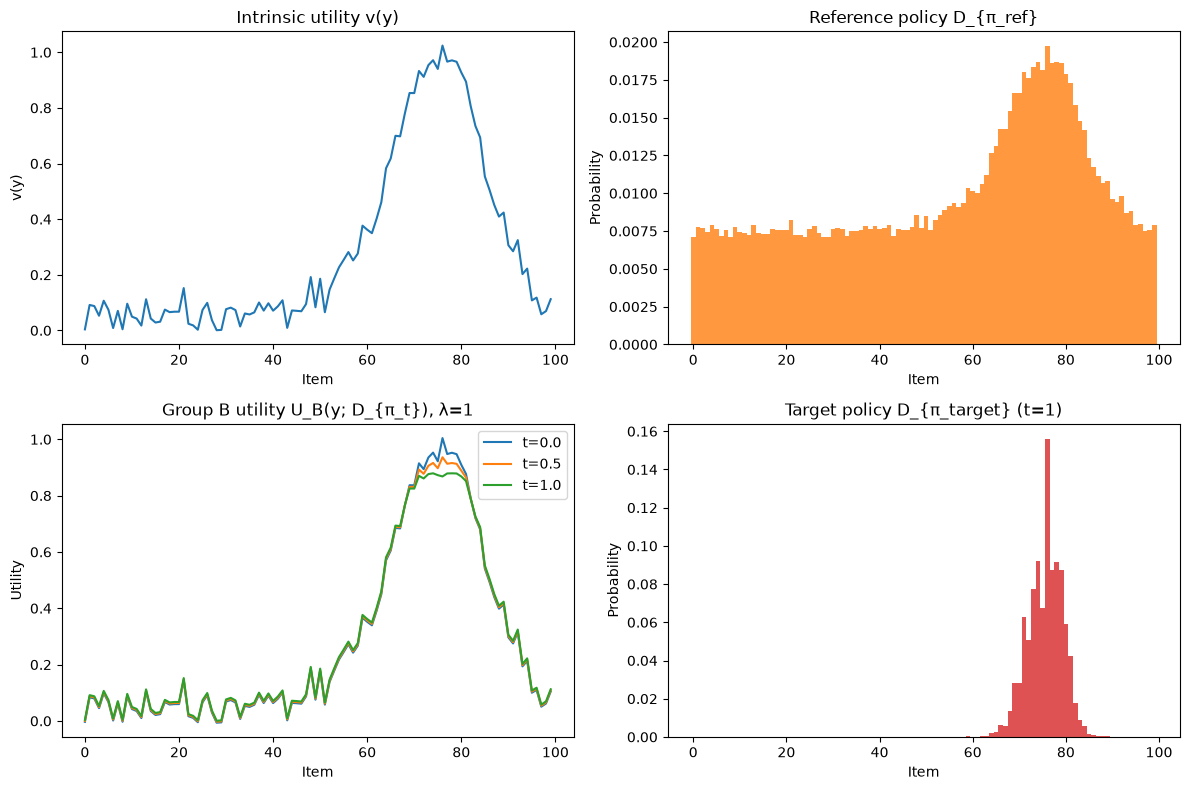

In [3]:
env = PreferenceEnvironment.create(config.env)
items = np.arange(env.n_items)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(items, env.v, color="tab:blue")
axes[0, 0].set_title("Intrinsic utility v(y)")
axes[0, 0].set_xlabel("Item")
axes[0, 0].set_ylabel("v(y)")

axes[0, 1].bar(items, env.pi_ref, width=1.0, color="tab:orange", alpha=0.8)
axes[0, 1].set_title("Reference policy D_{π_ref}")
axes[0, 1].set_xlabel("Item")
axes[0, 1].set_ylabel("Probability")

for t in [0.0, 0.5, 1.0]:
    pi_t = env.policy_at_t(t)
    u_b = env.utility_b(pi_t, lam=1.0)
    axes[1, 0].plot(items, u_b, label=f"t={t}")
axes[1, 0].set_title("Group B utility U_B(y; D_{π_t}), λ=1")
axes[1, 0].set_xlabel("Item")
axes[1, 0].set_ylabel("Utility")
axes[1, 0].legend()

axes[1, 1].bar(items, env.policy_at_t(1.0), width=1.0, color="tab:red", alpha=0.8)
axes[1, 1].set_title("Target policy D_{π_target} (t=1)")
axes[1, 1].set_xlabel("Item")
axes[1, 1].set_ylabel("Probability")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "exp1_environment.png", dpi=150)
plt.show()

In [4]:
result = run_experiment1(config)
df = result.results

print(f"Train pairwise accuracy: {result.train_accuracy:.3f}")
print(f"Val pairwise accuracy:   {result.val_accuracy:.3f}")
print(f"Sweep rows: {len(df)}")
df.head()

lambda sweep: 100%|██████████| 5/5 [00:00<00:00, 11.36it/s]

Train pairwise accuracy: 0.961
Val pairwise accuracy:   0.961
Sweep rows: 105


,lambda,t,js_divergence,spearman_rho,calibration_error,normalized_mse,pairwise_ranking_accuracy
0,0.0,0.00,0.000000,0.981002,0.04080,0.327934,0.95920
1,0.0,0.05,0.000966,0.981002,0.03800,0.327934,0.96200
2,0.0,0.10,0.003626,0.981002,0.03315,0.327934,0.96685
3,0.0,0.15,0.007739,0.981002,0.03260,0.327934,0.96740
4,0.0,0.20,0.013159,0.981002,0.02965,0.327934,0.97035


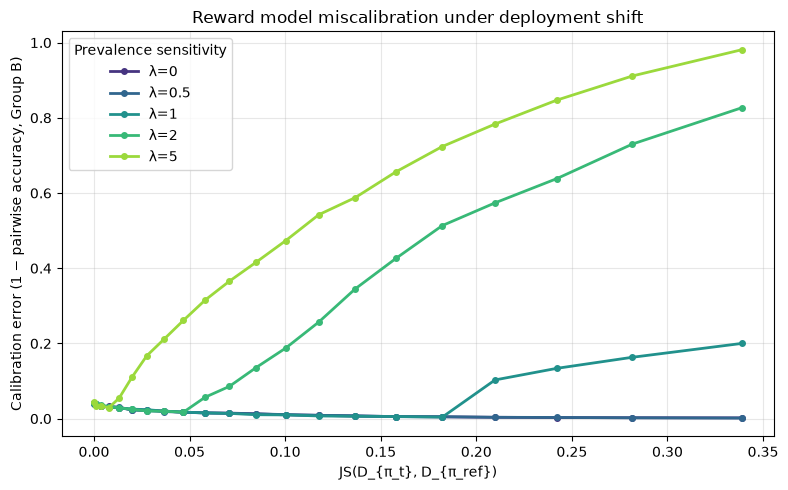

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

lambdas = sorted(df["lambda"].unique())
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(lambdas)))

for lam, color in zip(lambdas, colors):
    sub = df[df["lambda"] == lam].sort_values("js_divergence")
    ax.plot(
        sub["js_divergence"],
        sub["calibration_error"],
        marker="o",
        markersize=4,
        linewidth=2,
        color=color,
        label=f"λ={lam:g}",
    )

ax.set_xlabel("JS(D_{π_t}, D_{π_ref})")
ax.set_ylabel("Calibration error (1 − pairwise accuracy, Group B)")
ax.set_title("Reward model miscalibration under deployment shift")
ax.legend(title="Prevalence sensitivity")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "exp1_calibration_curve.png", dpi=150)
plt.show()

In [6]:
# Sanity checks
lam0 = df[df["lambda"] == 0.0].sort_values("t")
t0 = df[df["t"] == 0.0].sort_values("lambda")

print("λ=0 calibration error range:", lam0["calibration_error"].min(), "→", lam0["calibration_error"].max())
print("t=0 calibration error by λ:\n", t0[["lambda", "calibration_error", "spearman_rho"]].to_string(index=False))

# Monotonicity: calibration error vs JS for λ>0
for lam in [l for l in lambdas if l > 0]:
    sub = df[df["lambda"] == lam].sort_values("js_divergence")
    diffs = sub["calibration_error"].diff().dropna()
    violations = (diffs < -0.02).sum()
    print(f"λ={lam:g}: monotonicity violations (drop > 0.02): {violations}/{len(diffs)}")

df.to_csv(RESULTS_DIR / "exp1_results.csv", index=False)
print(f"\nSaved results to {RESULTS_DIR.relative_to(ROOT)}")

λ=0 calibration error range: 0.0021499999999999853 → 0.04079999999999995
t=0 calibration error by λ:
  lambda  calibration_error  spearman_rho
    0.0            0.04080      0.981002
    0.5            0.03935      0.981002
    1.0            0.04250      0.981002
    2.0            0.04225      0.981002
    5.0            0.04330      0.981002
λ=0.5: monotonicity violations (drop > 0.02): 0/20
λ=1: monotonicity violations (drop > 0.02): 0/20
λ=2: monotonicity violations (drop > 0.02): 0/20
λ=5: monotonicity violations (drop > 0.02): 0/20

Saved results to results
